In [1]:
import os
import json
import matplotlib.pyplot as plt

In [2]:

# get the input and output file paths
input_path = os.getenv('INPUT_PATH', 'src/main/resources/intermediate.json')
output_path = os.getenv('OUTPUT_PATH', 'src/main/resources/results.json')

In [3]:
# read the intermediate JSON file
with open(input_path, 'r') as f:
    data = json.load(f)

# display the data for debugging
print("Intermediate Data:", data)

Intermediate Data: {'LATA': [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 'twKI': [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15], 'twKS': [1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16], 'twINW': [1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17], 'twEKS': [1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18], 'twIMP': [1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19], 'KI': [100000.0, 110000.0, 120000.0, 130000.0, 140000.0, 150000.0, 160000.0, 170000.0, 180000.0, 190000.0, 200000.0, 210000.0, 220000.0, 230000.0, 240000.0], 'KS': [50000.0, 52000.0, 54000.0, 56000.0, 58000.0, 60000.0, 62000.0, 64000.0, 66000.0, 68000.0, 70000.0, 72000.0, 74000.0, 76000.0, 78000.0], 'INW': [70000.0, 72000.0, 74000.0, 76000.0, 78000.0, 80000.0, 82000.0, 84000.0, 8

In [4]:
years = data.get("LATA", [])
print(f"Years from LATA: {years}")

Years from LATA: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [5]:
# known fields to process
fields = [
    "twKI", "twKS", "twINW", "twEKS", "twIMP",
    "KI", "KS", "INW", "EKS", "IMP", "PKB", "ZDEKS", "NET_EXPORTS"
]

In [6]:
# extract  fields
PKB = data.get("PKB", [])
EKS = data.get("EKS", [])
IMP = data.get("IMP", [])

# calculate Export-to-GDP Ratio (ZDEKS)
ZDEKS = [eks / pkb if pkb != 0 else 0 for eks, pkb in zip(EKS, PKB)]
data["ZDEKS"] = ZDEKS
print("Calculated ZDEKS:", ZDEKS)

Calculated ZDEKS: [0.3175168380482046, 0.30300084113190756, 0.3226791270104657, 0.32198306043323843, 0.30239849942205044, 0.3076682557323443, 0.2818790644371293, 0.27520701750128057, 0.24720783361383214, 0.2481761454879437, 0.22664989596784316, 0.19614844851158358, 0.1789688256262873, 0.15322411621702367, 0.1315471712074495]


In [7]:
# build plots
def plot_data(fields, y_label, title, ylim=None, file_name="plot.png"):
    plt.figure(figsize=(12, 6))
    for field in fields:
        if field in data:
            plt.plot(data["LATA"], data[field], marker='o', label=field)
    plt.title(title, fontsize=16)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel(y_label, fontsize=14)
    if ylim:
        plt.ylim(ylim)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(file_name)
    plt.show()

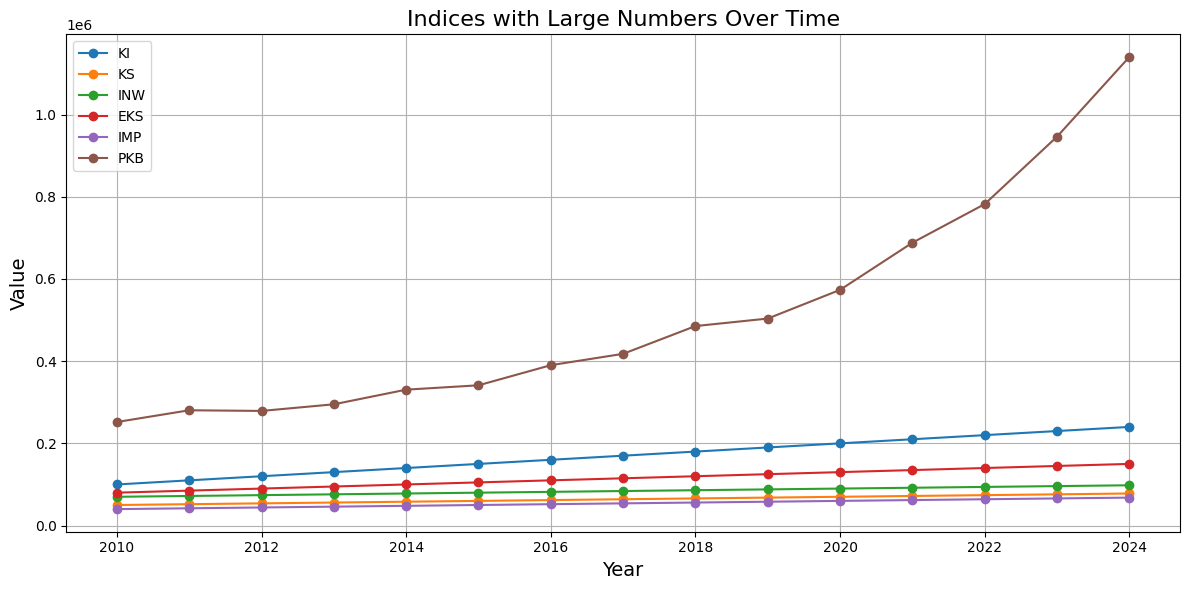

In [8]:
# plot large-number indices
plot_data(
    fields=["KI", "KS", "INW", "EKS", "IMP", "PKB", "NET_EXPORTS"],
    y_label="Value",
    title="Indices with Large Numbers Over Time",
    file_name="large_indices_plot.png"
)

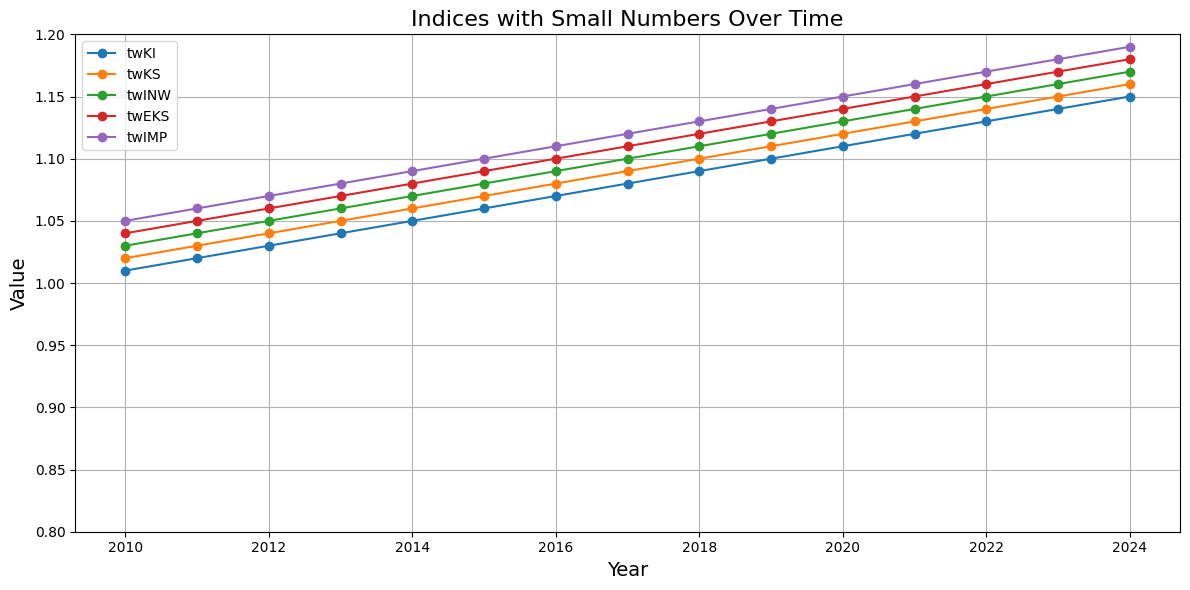

In [9]:
# small-number indices
plot_data(
    fields=["twKI", "twKS", "twINW", "twEKS", "twIMP"],
    y_label="Value",
    title="Indices with Small Numbers Over Time",
    ylim=(0.8, 1.2),  # Adjusted Y-axis range
    file_name="small_indices_plot.png"
)

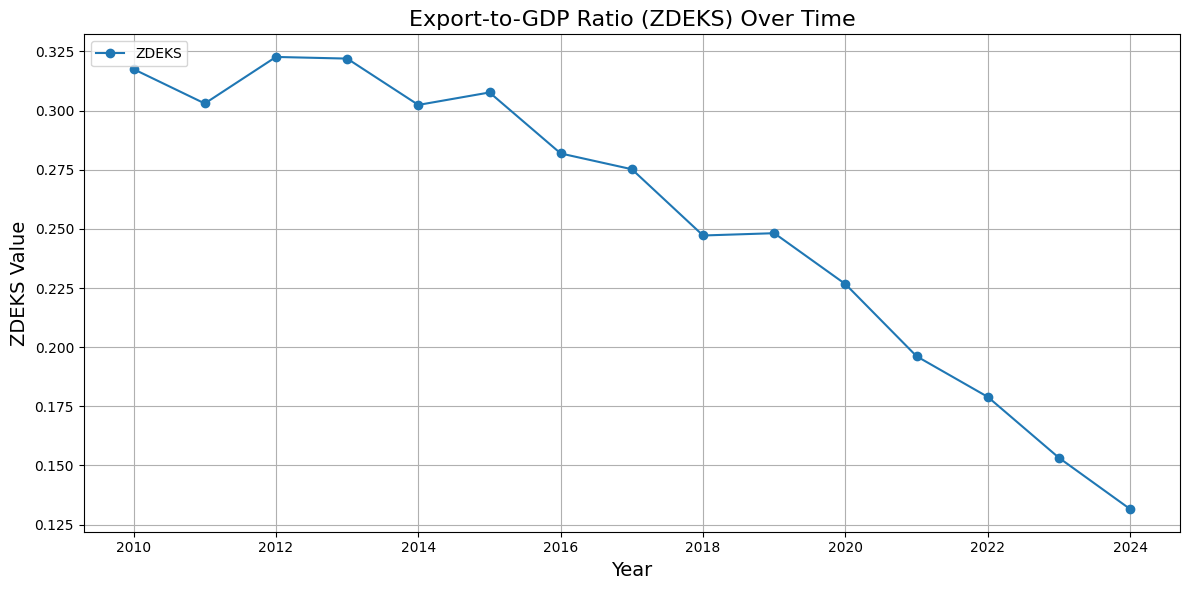

In [10]:
# plot ZDEKS
plot_data(
    fields=["ZDEKS"],
    y_label="ZDEKS Value",
    title="Export-to-GDP Ratio (ZDEKS) Over Time",
    file_name="zdeks_plot.png"
)

In [11]:
# write the updated results to the output JSON file
with open(output_path, 'w') as f:
    json.dump(data, f, indent=4)

print(f"Final results saved to {output_path}")

Final results saved to /Users/jakubgralinski/Desktop/studies/UTP/UTP_PRO_03/src/main/resources/results.json
